In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv(r'C:\Users\bharg\wind_power_forecasting\data\T1.csv')

In [11]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (50530, 5)

Columns: ['Date/Time', 'LV ActivePower (kW)', 'Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']

Missing Values:
 Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64


In [12]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%d %m %Y %H:%M')
df = df.set_index('Date/Time')
df = df.sort_index()

print("\nDate Range:", df.index.min(), "to", df.index.max())
print("Frequency:", pd.infer_freq(df.index))


Date Range: 2018-01-01 00:00:00 to 2018-12-31 23:50:00
Frequency: None


In [13]:
print("\nDescriptive Statistics:")
print(df.describe())

# Rename columns for easier use
df = df.rename(columns={
    'LV ActivePower (kW)': 'ActivePower',
    'Wind Speed (m/s)': 'WindSpeed',
    'Theoretical_Power_Curve (KWh)': 'TheoreticalPower',
    'Wind Direction (°)': 'WindDirection'
})


Descriptive Statistics:
       LV ActivePower (kW)  Wind Speed (m/s)  Theoretical_Power_Curve (KWh)  \
count         50530.000000      50530.000000                   50530.000000   
mean           1307.684332          7.557952                    1492.175463   
std            1312.459242          4.227166                    1368.018238   
min              -2.471405          0.000000                       0.000000   
25%              50.677890          4.201395                     161.328167   
50%             825.838074          7.104594                    1063.776283   
75%            2482.507568         10.300020                    2964.972462   
max            3618.732910         25.206011                    3600.000000   

       Wind Direction (°)  
count        50530.000000  
mean           123.687559  
std             93.443736  
min              0.000000  
25%             49.315437  
50%             73.712978  
75%            201.696720  
max            359.997589  


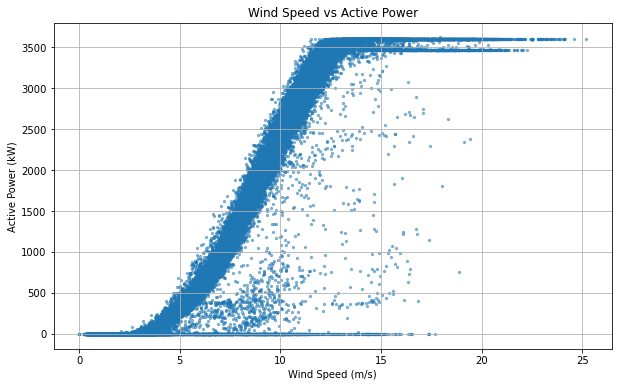

In [14]:
# Power vs Wind Speed Scatter (Core Relationship)
plt.figure(figsize=(10, 6))
plt.scatter(df['WindSpeed'], df['ActivePower'], alpha=0.5, s=5)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Active Power (kW)')
plt.title('Wind Speed vs Active Power')
plt.grid(True)
plt.show()

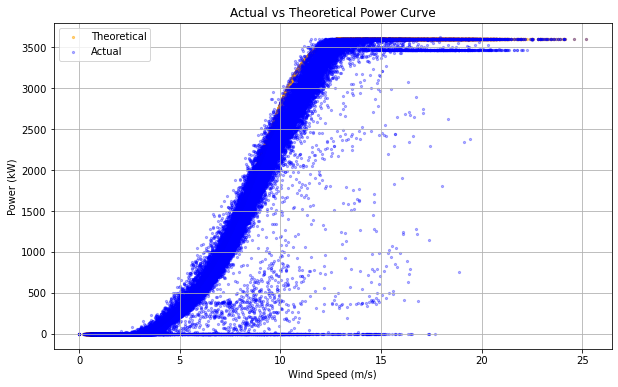

In [15]:
# Theoretical Power Curve
plt.figure(figsize=(10, 6))
plt.scatter(df['WindSpeed'], df['TheoreticalPower'], alpha=0.5, s=5, color='orange', label='Theoretical')
plt.scatter(df['WindSpeed'], df['ActivePower'], alpha=0.3, s=5, color='blue', label='Actual')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (kW)')
plt.title('Actual vs Theoretical Power Curve')
plt.legend()
plt.grid(True)
plt.show()